## **Deutsch - Josza Algorithm**

In [17]:
from qiskit import QuantumCircuit,transpile
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel
from qiskit_ibm_runtime.fake_provider import FakeAlgiers
from qiskit.visualization import plot_histogram
import numpy as np
from q_utils.style import dark_theme

#### *Oracle - Balanced function*

Randomly generated Integer (b): 15
Generated Binary Mask String (b_str): '11110'


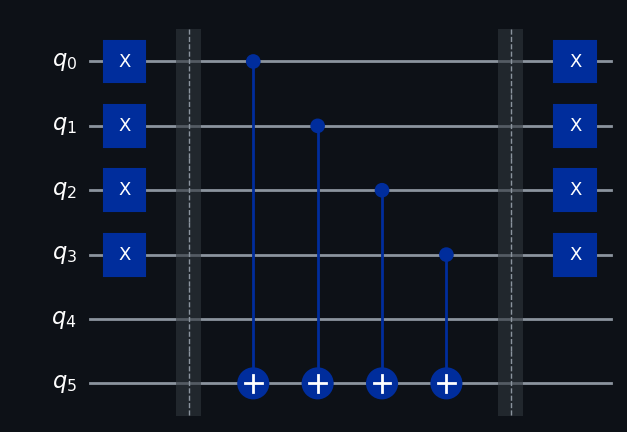

In [18]:
n = 5
b = np.random.randint(1,2**n)
b_string = format(b,'0'+str(n)+'b')
b_str = b_string[::-1]

bal_oracle = QuantumCircuit(n+1)

print(f"Randomly generated Integer (b): {b}")
print(f"Generated Binary Mask String (b_str): '{b_str}'")

for qubit in range(len(b_str)):
    if b_str[qubit] == '1':
            bal_oracle.x(qubit)

bal_oracle.barrier()

for qubit in range(len(b_str)):
    if b_str[qubit] == '1':
        bal_oracle.cx(qubit, n)
        
bal_oracle.barrier()

for qubit in range(len(b_str)):
    if b_str[qubit] == '1':
            bal_oracle.x(qubit)


bal_oracle.draw('mpl', style=dark_theme)

#### *Oracle - constant function*

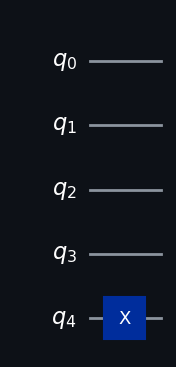

In [19]:
n = 4
con_oracle = QuantumCircuit(4+1)
output = np.random.randint(2)
if output == 1:
    con_oracle.x(n)
    
con_oracle.draw('mpl',style=dark_theme)

#### *Full algorithm for n qubits*

In [20]:
def dj_oracle(case, n):
    oracle = QuantumCircuit(n+1)
    
    if case == "balanced":
        b = np.random.randint(1, 2**n)
        b_string = format(b, '0'+str(n)+'b')
        b_str = b_string[::-1]
        
        for qubits in range(len(b_str)):
            if b_str[qubits] == '1':
                oracle.x(qubits)
        oracle.barrier()
        for qubits in range(len(b_str)):   
            if b_str[qubits] == '1':       
                oracle.cx(qubits, n)
        oracle.barrier()
        for qubits in range(len(b_str)):
            if b_str[qubits] == '1':
                oracle.x(qubits)
                
    elif case == 'constant':
        b = np.random.randint(2)
        if b == 1:
            oracle.x(n)
    
    return oracle

In [21]:
dj = QuantumCircuit(n+1,n)

def dj_algorithm(oracle,n):
    qc = QuantumCircuit(n+1,n)
    
    #ancilla qubit in |->
    qc.x(n)
    qc.h(n)
    
    for i in range(n):
        qc.h(i)
    
    qc.barrier()
    qc = qc.compose(oracle)
    qc.barrier()
    
    for i in range(n):
        qc.h(i)
        
    for i in range(n):
        qc.measure(i,i)
    
    return qc
    

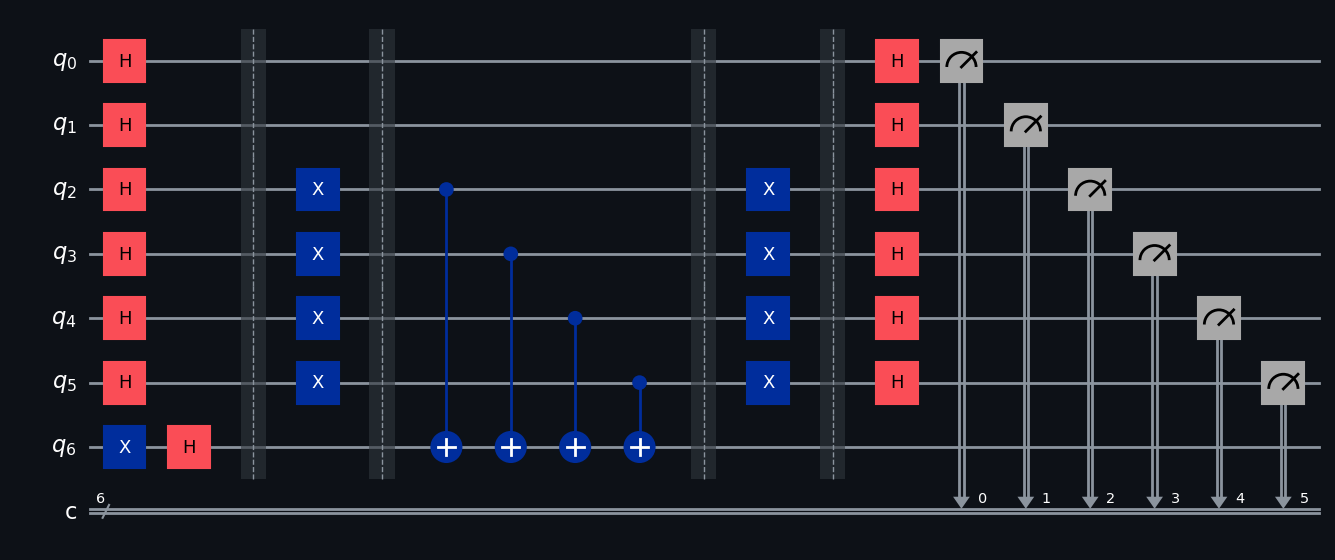

In [22]:
n = int(input("Enter the no of qubits:"))

oracle_function = ['constant','balanced']
case = np.random.choice(oracle_function)

oracle_instance = dj_oracle(case,n)
dj_circuit = dj_algorithm(oracle_instance,n)

dj_circuit.draw('mpl',style=dark_theme)


{'111100': 1024}


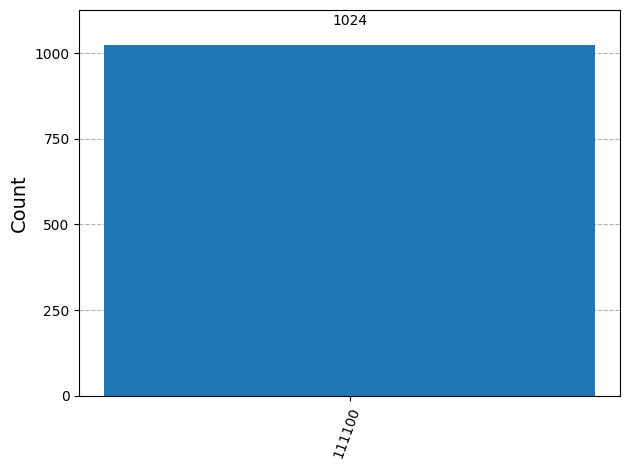

In [23]:
sim = AerSimulator()
transpiled_ct = transpile(dj_circuit,sim)
counts = sim.run(transpiled_ct,shots=1024).result().get_counts()
print(counts)
plot_histogram(counts)

#### *Noise Simulator*

{'111100': 955, '111101': 7, '101100': 5, '110100': 20, '111110': 12, '011100': 16, '111000': 8, '011000': 1}


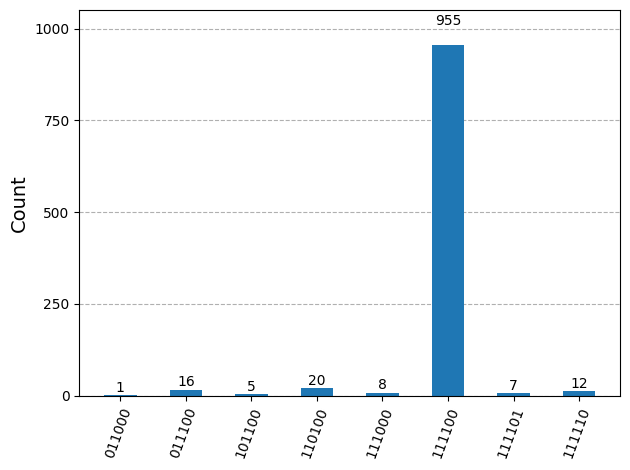

In [24]:
backend = FakeAlgiers()
noise_model = NoiseModel.from_backend(backend=backend)
sim_noise = AerSimulator(noise_model = noise_model)
transpiled_ct_noise = transpile(dj_circuit,sim_noise)
counts = sim_noise.run(transpiled_ct_noise,shots = 1024).result().get_counts()
print(counts)
plot_histogram(counts)